In [2]:
#1. Load --> Data, Model
#2. Preprocess
#3. Split ( Train, Test)
#4. Design and Implement out model. 
#5. Train
#6. Evaluate
#7. Predict

# Import Libraries

In [3]:
import os
import time
import json

import keras
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from keras.datasets import mnist
from keras.models import Sequential
from keras import layers
from keras.layers import Dense


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

I0000 00:00:1788797401.960124  142056 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788797401.962483  142056 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788797403.594821  142056 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788797406.746968  142056 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

# Load MNIST Dataset

In [4]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(f"Training images: {train_images.shape}")
print(f"Training labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}")
print(f"Test labels: {test_labels.shape}")

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## Visualize Sample Images

Before preprocessing, we visualize some examples from the MNIST dataset.

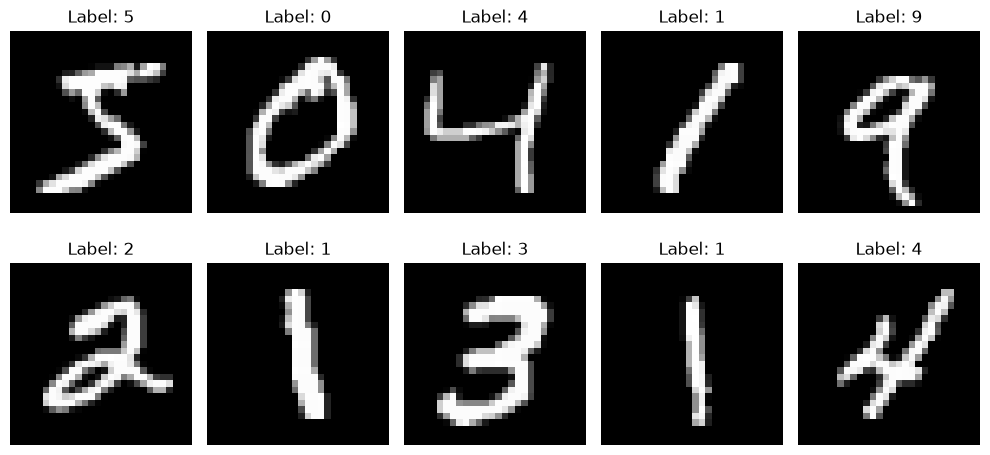

In [5]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

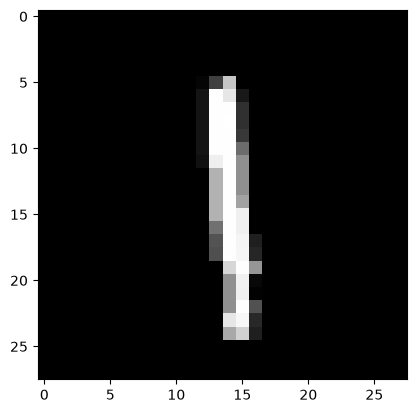

In [6]:
plt.imshow(train_images[8], cmap='gray')

In [7]:
train_labels[8]

np.uint8(1)

## One-Hot Encode Labels

The digit labels are converted into one-hot encoded vectors.

For example:

7 → [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

In [8]:
train_labels = keras.utils.to_categorical(train_labels)
test_labels = keras.utils.to_categorical(test_labels)

In [9]:
train_labels[8]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

# Normalize Images

Pixel values in MNIST range from 0 to 255.

We normalize them to the range [0, 1] to make the training process
more stable and efficient.

In [10]:
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

In [11]:
train_images[5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

# Prepare Data for Dense FFNN

## Flatten Images for Dense FFNN

A Dense Neural Network expects a one-dimensional input vector.

Each MNIST image has a shape of:

28 × 28 = 784

Therefore, each image is flattened into a vector of 784 values.

In [12]:
train_images_ffnn = train_images.reshape(60000, 784)
test_images_ffnn = test_images.reshape(10000, 784)

In [13]:
print("FFNN training shape:", train_images_ffnn.shape)
print("FFNN test shape:", test_images_ffnn.shape)

FFNN training shape: (60000, 784)
FFNN test shape: (10000, 784)


In [14]:
train_images_ffnn[5].shape

(784,)

## Data for CNN

# Prepare Images for CNN

CNN models expect image data in the following format:

(height, width, channels)

MNIST images are grayscale, so they have one channel.

Therefore, the input shape becomes:

28 × 28 × 1

In [15]:
train_images_cnn = np.expand_dims(train_images, axis=-1)
test_images_cnn = np.expand_dims(test_images, axis=-1)

In [16]:
train_images_cnn = np.expand_dims(train_images, axis=-1)
test_images_cnn = np.expand_dims(test_images, axis=-1)

In [17]:
print("CNN training shape:", train_images_cnn.shape)
print("CNN test shape:", test_images_cnn.shape)

CNN training shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


In [18]:
train_images_ffnn[5]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

# Build Dense FFNN

## Dense Feedforward Neural Network

The Dense FFNN receives the flattened 784-dimensional image.

Architecture:

Input: 784

↓

Dense: 128 neurons + ReLU

↓

Dense: 64 neurons + ReLU

↓

Output: 10 neurons + Softmax

In [30]:
## Design the model ffnn

model_ffnn = Sequential()
model_ffnn.add(Dense(128, activation="relu", input_shape=(784,))) #Dense, 128, Relu
model_ffnn.add(Dense(64, activation='relu'))#Dense, 64, Relu
model_ffnn.add(Dense(10, activation='softmax'))#Dense, 10, Softmax

## Compile FFNN

In [31]:
model_ffnn.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

# FFNN Summary

In [32]:
model_ffnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Build CNN



## Convolutional Neural Network

# The CNN processes the original spatial

# structure of the image.


Architecture:

Input: 28 × 28 × 1

↓

Conv2D: 32 filters

↓

MaxPooling

↓

Conv2D: 64 filters

↓

MaxPooling

↓

Conv2D: 128 filters

↓

MaxPooling

↓

Flatten

↓

Dense: 10 neurons

↓

Output: 10 classes

In [33]:
#Design
model_cnn = Sequential()

#Feature Extraction part
model_cnn.add(layers.Conv2D(
     32,
     kernel_size=(3, 3),
     padding='same',
     activation ='relu', 
     strides=(1, 1), 
     input_shape=(28, 28, 1)))

model_cnn.add(layers.MaxPool2D(pool_size=(2, 2)))

model_cnn.add(layers.Conv2D(
    64, 
    kernel_size=(3, 3), 
    padding='same', 
    activation = 'relu', 
    strides=(1, 1)))

model_cnn.add(layers.MaxPool2D(pool_size=(2, 2)))

model_cnn.add(layers.Conv2D(
    128, 
    kernel_size=(3, 3), 
    padding='same', 
    activation='relu', 
    strides=(1, 1)))
model_cnn.add(layers.MaxPool2D(pool_size=(2, 2)))

#Classification
model_cnn.add(layers.Flatten())
model_cnn.add(layers.Dense(10, activation='softmax'))

# Compile CNN

In [34]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
     metrics=['accuracy'])

# CNN Summary

In [35]:
model_cnn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

# Compare Number of Parameters
## Model Complexity

We compare the number of trainable parameters in both models.

In [36]:
ffnn_params = model_ffnn.count_params()
cnn_params = model_cnn.count_params()

print(f"Dense FFNN Parameters: {ffnn_params:,}")
print(f"CNN Parameters: {cnn_params:,}")

Dense FFNN Parameters: 109,386
CNN Parameters: 104,202


## Train Dense FFNN

The Dense FFNN is trained for 10 epochs using a batch size of 128.

Training time is measured for comparison with the CNN.

In [37]:
start_time = time.time()

ffnn_history = model_ffnn.fit(
    train_images_ffnn,
    train_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

ffnn_training_time = time.time() - start_time

print(f"FFNN Training Time: {ffnn_training_time:.2f} seconds")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9246 - loss: 0.2594 - val_accuracy: 0.9650 - val_loss: 0.1197
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9671 - loss: 0.1091 - val_accuracy: 0.9758 - val_loss: 0.0799
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9765 - loss: 0.0747 - val_accuracy: 0.9773 - val_loss: 0.0769
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9826 - loss: 0.0538 - val_accuracy: 0.9732 - val_loss: 0.0960
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9867 - loss: 0.0410 - val_accuracy: 0.9740 - val_loss: 0.0978
FFNN Training Time: 27.07 seconds


# Train CNN

In [39]:
start_time = time.time()

cnn_history = model_cnn.fit(
    train_images_cnn,
    train_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

cnn_training_time = time.time() - start_time

print(f"CNN Training Time: {cnn_training_time:.2f} seconds")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 0.9932 - val_loss: 0.0321
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9960 - loss: 0.0124 - val_accuracy: 0.9905 - val_loss: 0.0392
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.9971 - loss: 0.0083 - val_accuracy: 0.9917 - val_loss: 0.0369
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9975 - loss: 0.0075 - val_accuracy: 0.9925 - val_loss: 0.0454
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9976 - loss: 0.0073 - val_accuracy: 0.9908 - val_loss: 0.0429
CNN Training Time: 195.34 seconds


# Save Training Histories

In [40]:
os.makedirs("results", exist_ok=True)

with open("results/history_ffnn.json", "w") as file:
    json.dump(ffnn_history.history, file, indent=4)

with open("results/history_cnn.json", "w") as file:
    json.dump(cnn_history.history, file, indent=4)

print("Training histories saved successfully.")

Training histories saved successfully.


# Save Trained Models

In [42]:
os.makedirs("models", exist_ok=True)

model_ffnn.save("models/dense_ffnn.keras")
model_cnn.save("models/cnn.keras")

print("Models saved successfully.")

Models saved successfully.


# Make Predictions
The trained models are used to predict the classes of the MNIST test set.

In [45]:
ffnn_probabilities = model_ffnn.predict(
    test_images_ffnn,
    verbose=0
)

ffnn_predictions = np.argmax(
    ffnn_probabilities,
    axis=1
)

In [46]:
cnn_probabilities = model_cnn.predict(
    test_images_cnn,
    verbose=0
)

cnn_predictions = np.argmax(
    cnn_probabilities,
    axis=1
)

In [47]:
test_labels_original = np.argmax(test_labels, axis=1)

# Calculate Metrics
## Model Evaluation

We evaluate both models using:

- Accuracy
- Precision
- Recall
- F1-Score

In [48]:
ffnn_accuracy = accuracy_score(
    test_labels_original,
    ffnn_predictions
)

ffnn_precision = precision_score(
    test_labels_original,
    ffnn_predictions,
    average="weighted",
    zero_division=0
)

ffnn_recall = recall_score(
    test_labels_original,
    ffnn_predictions,
    average="weighted",
    zero_division=0
)

ffnn_f1 = f1_score(
    test_labels_original,
    ffnn_predictions,
    average="weighted",
    zero_division=0
)

In [49]:
cnn_accuracy = accuracy_score(
    test_labels_original,
    cnn_predictions
)

cnn_precision = precision_score(
    test_labels_original,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

cnn_recall = recall_score(
    test_labels_original,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

cnn_f1 = f1_score(
    test_labels_original,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

In [50]:
# Print Results
print("Dense FFNN")
print(f"Accuracy : {ffnn_accuracy:.4f}")
print(f"Precision: {ffnn_precision:.4f}")
print(f"Recall   : {ffnn_recall:.4f}")
print(f"F1-Score : {ffnn_f1:.4f}")

print("\nCNN")
print(f"Accuracy : {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall   : {cnn_recall:.4f}")
print(f"F1-Score : {cnn_f1:.4f}")

Dense FFNN
Accuracy : 0.9695
Precision: 0.9704
Recall   : 0.9695
F1-Score : 0.9696

CNN
Accuracy : 0.9883
Precision: 0.9885
Recall   : 0.9883
F1-Score : 0.9883


# Confusion Matrix — FFNN

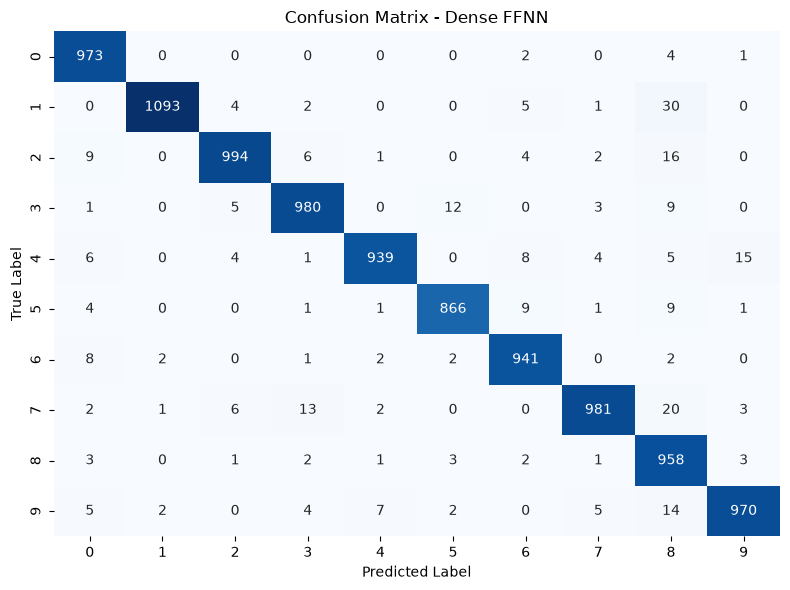

In [51]:
os.makedirs("plots", exist_ok=True)

ffnn_cm = confusion_matrix(
    test_labels_original,
    ffnn_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    ffnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix - Dense FFNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix_ffnn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Confusion Matrix — CNN

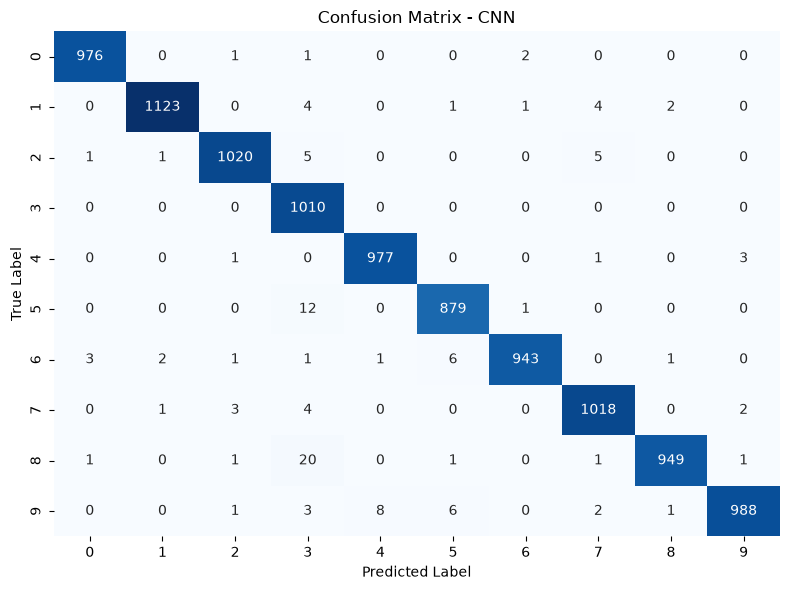

In [52]:
cnn_cm = confusion_matrix(
    test_labels_original,
    cnn_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix_cnn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()